In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)

X = iris.data.values
y = iris.target.values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

# Regression metrics

### 1. Mean Absolute Error (MAE)

**Mathematical Formula:**
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**Definition:** The average of absolute differences between predicted and actual values.

**Characteristics:**
- Robust to outliers
- Interpretable (same units as target)
- Not differentiable at zero

In [37]:
from sklearn.metrics import mean_absolute_error

y_true = np.array([3.0, -0.5, 2.0, 7.0])
y_pred = np.array([2.5, 0.0, 2.0, 8.0])

mae = mean_absolute_error(y_true, y_pred)
mae

0.5

### 2. Mean Squared Error (MSE)

**Mathematical Formula:**
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Definition:** The average of squared differences between predicted and actual values.

**Characteristics:**
- Penalizes large errors more heavily
- Differentiable everywhere
- Sensitive to outliers


In [38]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true, y_pred)
mse

0.375

### 3. Root Mean Squared Error (RMSE)

**Mathematical Formula:**
$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} = \sqrt{\text{MSE}}$$

**Definition:** The square root of MSE, providing error in the same units as the target.

**Characteristics:**
- Same units as target variable
- More interpretable than MSE
- Still sensitive to outliers

In [39]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_true, y_pred)
rmse

0.6123724356957945


### 4. R² Score (Coefficient of Determination)

**Mathematical Formula:**
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$

Where:
- $\text{SS}_{\text{res}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ (Residual Sum of Squares)
- $\text{SS}_{\text{tot}} = \sum_{i=1}^{n} (y_i - \bar{y})^2$ (Total Sum of Squares)
- $\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$ (Mean of actual values)

**Definition:** The proportion of variance in the dependent variable that is predictable from the independent variables.

**Interpretation:**
- R² = 1.0: Perfect fit
- R² = 0.0: Model predicts the mean as well as any model
- R² < 0: Model performs worse than predicting the mean

**Characteristics:**
- Scale-independent
- Can be negative
- Increases with more predictors (use Adjusted R² for multiple regression)


In [40]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)
r2

0.9486081370449679

### 5. Adjusted R²

**Mathematical Formula:**
$$R^2_{\text{adj}} = 1 - (1 - R^2) \frac{n - 1}{n - p - 1}$$

Where:
- $n$ = number of observations
- $p$ = number of predictors

**Definition:** Adjusted R² that accounts for the number of predictors in the model.

In [41]:
def adjusted_r2_score(y_true, y_pred, n_features):
    n = len(y_true)
    p = n_features
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

adj_r2 = adjusted_r2_score(y_true, y_pred, n_features=X.shape[1])
adj_r2

1.1541755888650962

### 6. Mean Absolute Percentage Error (MAPE)

**Mathematical Formula:**
$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

**Definition:** The average of absolute percentage errors.

**Characteristics:**
- Scale-independent (percentage)
- Undefined when actual values are zero
- Asymmetric (penalizes underestimates more)

In [42]:
# def mean_absolute_percentage_error(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     return np.mean(np.abs((y_true - y_pred) / y_true))

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true, y_pred)
mape

0.3273809523809524

### 7. Huber Loss

**Mathematical Formula:**
$$\text{Huber}(y, \hat{y}) = \begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| \leq \delta \\
\delta(|y - \hat{y}| - \frac{1}{2}\delta) & \text{otherwise}
\end{cases}$$

**Definition:** A loss function that is quadratic for small errors and linear for large errors, providing robustness to outliers.

In [43]:
def huber_loss_np(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    abs_error = np.abs(error)
    # Calculate quadratic and linear components
    quadratic_loss = 0.5 * error**2
    linear_loss = delta * (abs_error - 0.5 * delta)
    
    # Use np.where to select the appropriate loss
    loss = np.where(abs_error <= delta, quadratic_loss, linear_loss)
    return np.mean(loss) # or np.sum(loss) or no reduction

huber_loss_np(y_true, y_pred, delta=1.0)

np.float64(0.1875)

## Classification Metrics

In [25]:
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
y_pred = lr_clf.predict(X_test)
y_pred

array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1,
       0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0])

In [45]:
y_test

array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 2,
       0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0])

In [55]:
y_pred[y_pred != y_test], y_test[y_pred != y_test]

(array([1]), array([2]))

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[16,  0,  0],
       [ 0,  8,  0],
       [ 0,  1, 13]])

For $n$ classes, the confusion matrix is an $n \times n$ matrix where element $(i, j)$ contains the count of instances with true class $i$ predicted as class $j$.

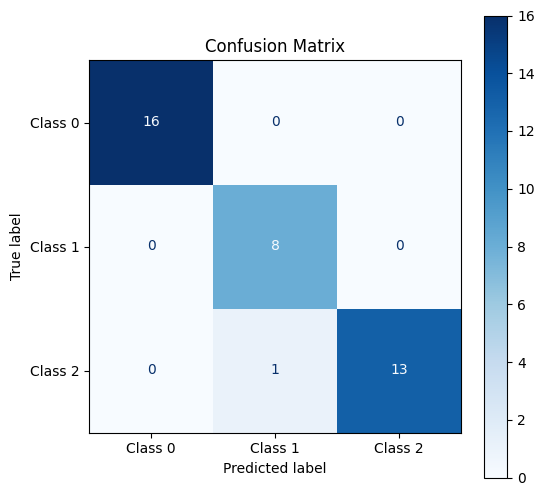

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1', 'Class 2'])
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

For multi-class classification with $n$ classes:
$$\text{Accuracy} = \frac{\sum_{i=1}^{n} \text{CM}_{i,i}}{N}$$

Where $\text{CM}_{i,i}$ is the diagonal element (correct predictions) for class $i$, and $N$ is the total number of instances.

**Definition:** The proportion of correctly classified instances out of all instances.

**Limitations:** Accuracy can be misleading for imbalanced datasets. For multi-class problems with class imbalance, consider using balanced accuracy or other metrics.

In [61]:
from sklearn.metrics import accuracy_score

accuracy_multiclass = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy_multiclass:.4f}")

# Or manually from confusion matrix:
accuracy_from_cm = np.trace(cm) / np.sum(cm)


Accuracy: 0.9737


In [62]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

Balanced Accuracy: 0.9762


In [10]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
cross_val_score(dummy_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.36842105, 0.37837838, 0.37837838])

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

for train_index, test_index in skfolds.split(X_train, y_train):
    clone_clf = clone(lr_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

1.0
0.918918918918919
0.9459459459459459


In [ ]:
from sklearn.preprocessing import TargetEncoder, LabelEncoder
LabelEncoder